In [3]:
import pandas as pd
import numpy as np
import statsmodels.formula.api as smf
import seaborn as sns
from sklearn.preprocessing import PowerTransformer
from sklearn.decomposition import PCA
from scipy import stats
import matplotlib.pyplot as plt

In [4]:
sns.set_context("paper", font_scale=1.5)
sns.set_style("white")
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial', 'Helvetica']

In [5]:
pt = PowerTransformer(standardize=True)

In [6]:
import statsmodels
print(statsmodels.__version__)

0.14.4


In [7]:
def reportMetrics(fitResut,data=[],fe_vars=[]):
    var_intercept = fitResut.cov_re.iloc[0, 0]
    var_residual = fitResut.scale
    pval= fitResut.pvalues
    icc = var_intercept / (var_intercept + var_residual)
    k = len(fitResut.params) +2
    n = fitResut.nobs
    aic = -2 * fitResut.llf + 2 * k
    bic = -2 * fitResut.llf + np.log(n) * k
    fe_params = fitResut.params
    fe_se = fitResut.bse
    fe_ci = fitResut.conf_int()
    stats = {
        "AIC/BIC": f"{aic:.1f}/{bic:.1f}",
        "ICC": f"{icc:.3f}",
        "Intercept": f"{fe_params['Intercept']:.3f}\u00B1{fe_se['Intercept']:.3f} (p={pval['Intercept']:.3f}) [{fe_ci.loc['Intercept', 0]:.3f}, {fe_ci.loc['Intercept', 1]:.3f}]",
        "Subject_Var": f"{var_intercept:.3f}",
        "Residual_Var": f"{var_residual:.3f}"
    }
    if len(data) > 0:
        fixed_predictions = fitResut.predict(data) 
        var_fixed = np.var(fixed_predictions)
        # R2_m = var_fixed / (var_fixed + var_random + var_residual)
        marginal_r2 = var_fixed / (var_fixed + var_intercept + var_residual)
        # R2_c = (var_fixed + var_random) / (var_fixed + var_random + var_residual)
        stats["Marginal_R2"]= f"{marginal_r2:.3f}"
        stats["Conditional_R2"]= f"{(var_fixed + var_intercept) / (var_fixed + var_intercept + var_residual):.3f}"
        for var in fe_vars:
            stats[var]=f"{fe_params[var]:.3f}\u00B1{fe_se[var]:.3f} (p={pval[var]:.3f}) [{fe_ci.loc[var, 0]:.3f}, {fe_ci.loc[var, 1]:.3f}]"
    return stats

# Study 1

In [13]:
datafolder='Data/To/Study1'
projectfolder='Project/Study1'
cueType={}
cueType['pos']=['complete','finish','improved','memories','imagine','aspire','opportunity','admired']
cueType['neg']=['failure','shame','mistake','threat','remorse','uncertain','worry','death']

In [33]:
featurelist=['ppx_m','semdis','valence_m','valence_vol','fluency']
cfaResultTrial=pd.read_csv(projectfolder+'result/Study1.csv').drop(columns=['Unnamed: 0']) #llama, limit

cfaResultTrial['cueType']=np.nan
cfaResultTrial.loc[cfaResultTrial['cue'].isin(cueType['neg']),'cueType']='neg'
cfaResultTrial.loc[cfaResultTrial['cue'].isin(cueType['pos']),'cueType']='pos'
cfaResultTrial[featurelist]=pt.fit_transform(cfaResultTrial[featurelist])

/var/folders/f4/kqf7rn397cj8ynryplksbjvm0000gr/T/ipykernel_90499/1680749667.py:5: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'neg' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  cfaResultTrial.loc[cfaResultTrial['cue'].isin(cueType['neg']),'cueType']='neg'


            PHQ9
count  79.000000
mean    5.012658
std     4.286214
min     0.000000
25%     2.000000
50%     4.000000
75%     7.000000
max    20.000000


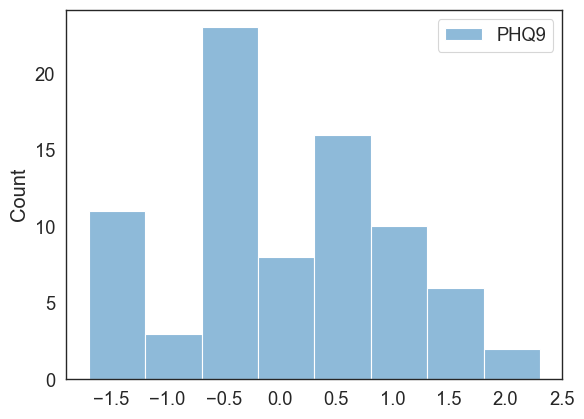

In [35]:
questionnaire=pd.read_excel('/Users/yuhuayu/Documents/spontaneous thought/DT/DT_questionnaires.xlsx')
questionnaire.rename(columns={'PHQ9.score':'PHQ9'},inplace=True)
questionnaire['subid']=questionnaire['ID'].astype(int)
print(questionnaire[['PHQ9']].describe())
questionnaire['PHQ9_raw']=questionnaire['PHQ9']
questionnaire[['PHQ9']]=pt.fit_transform(questionnaire[['PHQ9']])
sns.histplot(questionnaire[['PHQ9']])
plt.show()

In [37]:
cfaResultTrial=cfaResultTrial[['subid','cue','cueType']+featurelist].merge(questionnaire[['subid','PHQ9']],left_on='subid',right_on='subid',how='left')
cfaResultTrial.describe()

,subid,ppx_m,semdis,valence_m,valence_vol,fluency,PHQ9
count,1024.000000,1.019000e+03,1.019000e+03,1.019000e+03,1.019000e+03,1.024000e+03,880.000000
mean,37.468750,2.022153e-16,5.787541e-16,1.045941e-17,-3.521335e-16,-2.636780e-16,-0.112068
std,21.266245,1.000491e+00,1.000491e+00,1.000491e+00,1.000491e+00,1.000489e+00,1.027511
min,2.000000,-3.499410e+00,-3.695422e+00,-2.167884e+00,-2.518377e+00,-2.186179e+00,-1.695324
25%,20.750000,-6.513875e-01,-6.161288e-01,-7.294975e-01,-7.053756e-01,-7.237703e-01,-0.610308
50%,37.500000,3.519005e-02,-1.202432e-02,3.087690e-02,2.739810e-03,3.313278e-02,-0.269121
75%,53.250000,6.251055e-01,6.263833e-01,7.420594e-01,7.528401e-01,1.061370e+00,0.475184
max,94.000000,4.298466e+00,3.160920e+00,2.396488e+00,2.982272e+00,2.423058e+00,2.306286


In [23]:
cfaResultTrial[featurelist].corr()

,ppx_m,semdis_m,semdis_mall,valence_m,valence_vol,count,count_gen
ppx_m,1.000000,0.193368,0.091570,0.072969,0.199368,0.194146,0.120013
semdis_m,0.193368,1.000000,0.847477,0.206135,0.028629,0.034338,0.028366
semdis_mall,0.091570,0.847477,1.000000,0.245967,0.016883,0.131039,0.082003
valence_m,0.072969,0.206135,0.245967,1.000000,-0.244536,0.119149,0.104119
valence_vol,0.199368,0.028629,0.016883,-0.244536,1.000000,0.067976,0.050816
count,0.194146,0.034338,0.131039,0.119149,0.067976,1.000000,0.888448
count_gen,0.120013,0.028366,0.082003,0.104119,0.050816,0.888448,1.000000


In [25]:
len(cfaResultTrial['subid'].unique())

64

In [39]:
t='PHQ9'
fe_vars=["PHQ9","seedType","seedType:PHQ9"]
output={}
cfaResultTrial['seedType']=cfaResultTrial['cueType'].map({'neg':-0.5,'pos':0.5})
for f in featurelist:
    print('\n',f)
    tmp=cfaResultTrial[['seedType',f,'subid',t]].dropna()

    model = smf.mixedlm(f"{f} ~ 1", 
                data=tmp, 
                groups=tmp["subid"])
    result1=model.fit(method='powell', maxiter=2000)
    stats1= reportMetrics(result1)
    stats1['model']='Null'
    #print(f'Null Model:  icc={icc:.2f}, aic={aic:.2f}, bic = {bic:.2f}')
    #print(result1.summary())
    model = smf.mixedlm(f"{f} ~  seedType *{t}", 
                data=tmp, 
                groups=tmp["subid"])
    result2=model.fit(method='powell', maxiter=2000)
    print(result2.summary())
    stats2 = reportMetrics(result2,data=tmp,fe_vars=fe_vars)
    stats2['model']='Full'
    
    # Automatically grabs the interaction term (e.g., 'cue_effect:PHQ9')
    interaction_name = f"seedType:{t}"
    
    constraint_neg = result2.model.data.design_info.linear_constraint(f"{t}-0.5*{interaction_name}=0")
    slope_neg = result2.t_test(constraint_neg.coefs)

    print("\n--- Simple Slope: Negative Seeds ---")
    print(slope_neg.summary())
    
    constraint_pos = result2.model.data.design_info.linear_constraint(f"{t}+0.5*{interaction_name}=0")
    slope_pos = result2.t_test(constraint_pos.coefs)
    print("\n--- Simple Slope: Positive Seeds ---")
    print(slope_pos.summary())

    output[f]=(pd.DataFrame([stats1,stats2],columns=['model','Intercept']+fe_vars+['Random_Effect','Subject_Var','Residual_Var','Fit','ICC','AIC/BIC','Marginal_R2']).set_index('model').T.fillna(''))


 ppx_m


         Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: ppx_m     
No. Observations: 876     Method:             REML      
No. Groups:       55      Scale:              0.7845    
Min. group size:  15      Log-Likelihood:     -1180.7821
Max. group size:  16      Converged:          Yes       
Mean group size:  15.9                                  
--------------------------------------------------------
              Coef.  Std.Err.   z    P>|z| [0.025 0.975]
--------------------------------------------------------
Intercept      0.026    0.061  0.429 0.668 -0.093  0.145
seedType       0.030    0.060  0.498 0.618 -0.088  0.148
PHQ9           0.135    0.059  2.307 0.021  0.020  0.250
seedType:PHQ9 -0.057    0.058 -0.977 0.329 -0.171  0.057
Group Var      0.150    0.045                           


--- Simple Slope: Negative Seeds ---
                             Test for Constraints                             
                 coef    std err     

         Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: semdis    
No. Observations: 876     Method:             REML      
No. Groups:       55      Scale:              0.7492    
Min. group size:  15      Log-Likelihood:     -1157.3397
Max. group size:  16      Converged:          Yes       
Mean group size:  15.9                                  
--------------------------------------------------------
               Coef. Std.Err.   z    P>|z| [0.025 0.975]
--------------------------------------------------------
Intercept      0.010    0.056  0.171 0.864 -0.099  0.118
seedType       0.651    0.059 11.064 0.000  0.536  0.767
PHQ9           0.034    0.054  0.635 0.526 -0.071  0.139
seedType:PHQ9  0.088    0.057  1.552 0.121 -0.023  0.200
Group Var      0.121    0.039                           


--- Simple Slope: Negative Seeds ---
                             Test for Constraints                             
                 coef    std err     

         Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: valence_m 
No. Observations: 876     Method:             REML      
No. Groups:       55      Scale:              0.6356    
Min. group size:  15      Log-Likelihood:     -1068.4414
Max. group size:  16      Converged:          Yes       
Mean group size:  15.9                                  
--------------------------------------------------------
              Coef.  Std.Err.   z    P>|z| [0.025 0.975]
--------------------------------------------------------
Intercept      0.011    0.037  0.308 0.758 -0.061  0.084
seedType       1.111    0.054 20.501 0.000  1.005  1.218
PHQ9          -0.019    0.036 -0.531 0.595 -0.089  0.051
seedType:PHQ9 -0.195    0.052 -3.711 0.000 -0.297 -0.092
Group Var      0.034    0.019                           


--- Simple Slope: Negative Seeds ---
                             Test for Constraints                             
                 coef    std err     

          Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: valence_vol
No. Observations: 876     Method:             REML       
No. Groups:       55      Scale:              0.8134     
Min. group size:  15      Log-Likelihood:     -1183.3668 
Max. group size:  16      Converged:          Yes        
Mean group size:  15.9                                   
---------------------------------------------------------
               Coef.  Std.Err.   z    P>|z| [0.025 0.975]
---------------------------------------------------------
Intercept      -0.002    0.048 -0.038 0.970 -0.096  0.092
seedType       -0.536    0.061 -8.741 0.000 -0.656 -0.416
PHQ9            0.141    0.047  3.024 0.002  0.050  0.232
seedType:PHQ9  -0.036    0.059 -0.611 0.541 -0.152  0.080
Group Var       0.075    0.028                           


--- Simple Slope: Negative Seeds ---
                             Test for Constraints                             
                 coef 

         Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: fluency   
No. Observations: 880     Method:             REML      
No. Groups:       55      Scale:              0.5594    
Min. group size:  16      Log-Likelihood:     -1066.1914
Max. group size:  16      Converged:          Yes       
Mean group size:  16.0                                  
--------------------------------------------------------
              Coef.  Std.Err.   z    P>|z| [0.025 0.975]
--------------------------------------------------------
Intercept      0.081    0.087  0.925 0.355 -0.090  0.251
seedType       0.140    0.051  2.752 0.006  0.040  0.239
PHQ9          -0.081    0.084 -0.957 0.339 -0.246  0.085
seedType:PHQ9  0.037    0.049  0.745 0.456 -0.060  0.133
Group Var      0.377    0.110                           


--- Simple Slope: Negative Seeds ---
                             Test for Constraints                             
                 coef    std err     

In [41]:
with pd.ExcelWriter(projectfolder+'writeup/study1_export.xlsx') as writer:
    for f in featurelist:
        output[f].to_excel(writer,sheet_name=f)

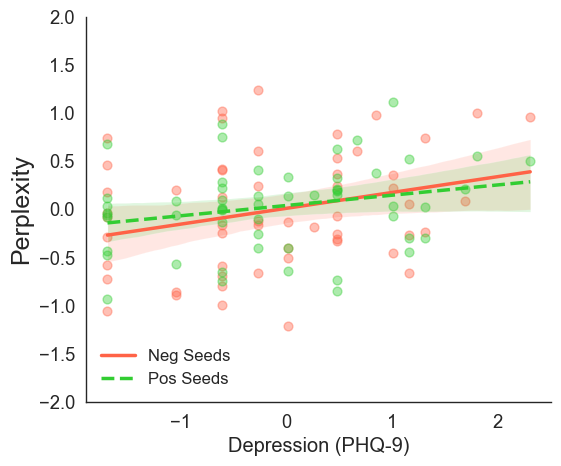

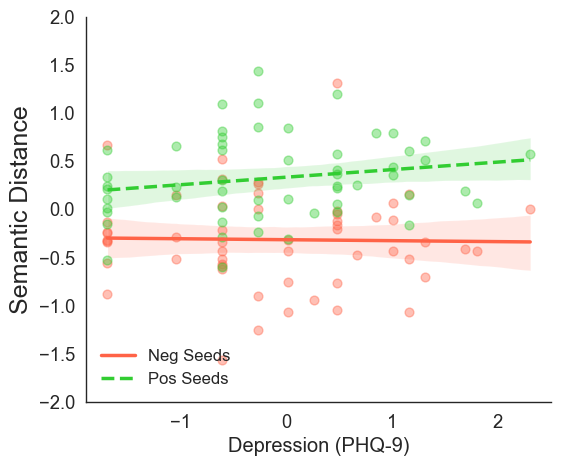

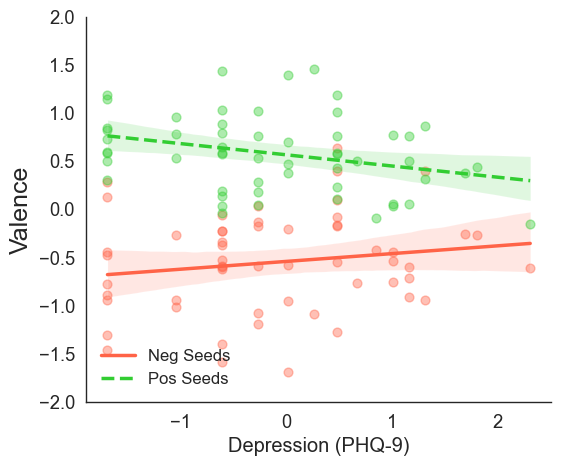

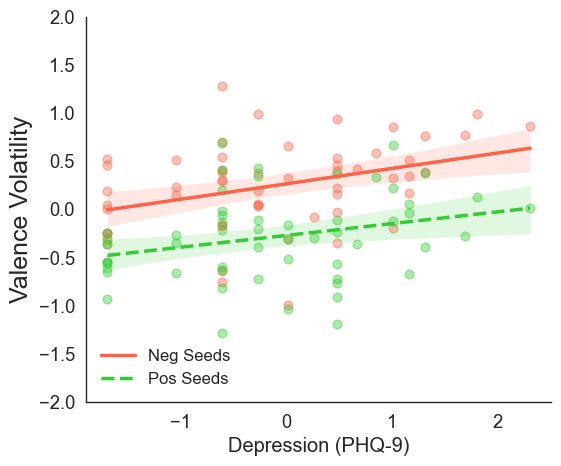

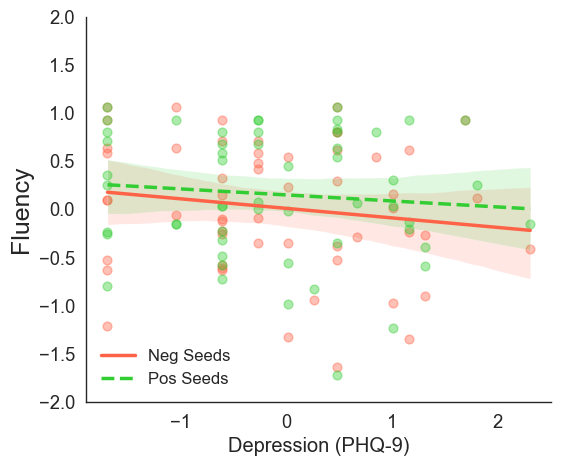

In [49]:
t='PHQ9'
ylabels={'ppx_m':'Perplexity','semdis':'Semantic Distance','valence_m':'Valence','valence_vol':'Valence Volatility','fluency':'Fluency'}
for f in ['ppx_m','semdis','valence_m','valence_vol','fluency']:
    tmp=cfaResultTrial[['cueType',f,'subid',t]].dropna()
    tmp=tmp.groupby(['subid','cueType']).mean().reset_index()

    fig,ax=plt.subplots(figsize=(6, 5))
    sns.regplot(y=f, x=t, data=tmp[tmp['cueType']=='neg'], ax=ax, color='tomato',
                scatter_kws={'alpha':0.4, 's':40}, line_kws={'lw':2.5,'label':'Neg Seeds'})
    sns.regplot(y=f, x=t, data=tmp[tmp['cueType']=='pos'], ax=ax, color='limegreen', 
                scatter_kws={'alpha':0.4, 's':40}, line_kws={'lw':2.5,'linestyle': "--",'label':'Pos Seeds'})
    #ax.set_title('Semantic Entrapment', fontweight='bold', pad=15)
    ax.set_xlabel('Depression (PHQ-9)')
    ax.set_ylim(-2,2)
    #ax.set_xlabel('Curiosity and Exploration (CEII)')
    ax.set_ylabel(ylabels[f],fontsize=18)
    ax.legend(frameon=False, loc='lower left', fontsize=12)
    sns.despine()
    plt.show()
    plt.close()


# Study 2

In [51]:
datafolder='Data/To/Study2'
projectfolder='Project/Study2'
cueType={}
cueType['pos']=['FUTURE','TRIP','WIN','BEAUTIFUL','SPOUSE','FATHER','HEART']
cueType['neg']=['ALONE','JEALOUSY','FAILURE','WORRY','SHAME','PAIN','CRISIS']
cueType['neu']=['NOISE','WANT','TEACH','BREATH','ADVICE','BEGINNING','MEMORY']


In [53]:
excludeID=[853,959,983,1988,1229] # very poor CFA performance
featurelist=['ppx_m','semdis','valence_m','valence_vol','fluency']
cfaResultTrial=pd.read_csv(projectfolder+'result/Study2.csv').drop(columns=['Unnamed: 0'])

cfaResultTrial=cfaResultTrial[~cfaResultTrial['subid'].isin(excludeID)]
cfaResultTrial['cueType']=''
cfaResultTrial.loc[cfaResultTrial['cue'].isin(cueType['neg']),'cueType']='neg'
cfaResultTrial.loc[cfaResultTrial['cue'].isin(cueType['pos']),'cueType']='pos'
cfaResultTrial.loc[cfaResultTrial['cue'].isin(cueType['neu']),'cueType']='neu'
cfaResultTrial[featurelist]=pt.fit_transform(cfaResultTrial[featurelist])

In [55]:
questionnaire=pd.read_excel(datafolder+'Questionnaires_YY.xlsx',sheet_name='data').drop(columns=['Box_BroodRum','RRS_BroodRum']).set_index('ID')
pca = PCA(n_components=1)
depressfeatures=['BDI_Sum','RRS_Brood','RRS_Depression','RRS_Rumination']
depressfeatures=['BDI_Sum','RRS_Depression']
clean_indices = questionnaire[depressfeatures].dropna().index
X_gaussian = pt.fit_transform(questionnaire.loc[clean_indices,depressfeatures])
questionnaire.loc[clean_indices, 'pc1'] = pca.fit_transform(X_gaussian)

In [57]:
questionnaire.loc[clean_indices,depressfeatures].corr()

,BDI_Sum,RRS_Depression
BDI_Sum,1.000000,0.772278
RRS_Depression,0.772278,1.000000


In [59]:
cfaResultTrial=cfaResultTrial[['subid','cue','cueType']+featurelist].merge(questionnaire[['pc1','gender']].reset_index().rename(columns={'ID':'subid'}),on='subid',how='left')
cfaResultTrial.describe()

,subid,ppx_m,semdis,valence_m,valence_vol,fluency,pc1
count,1869.00000,1.867000e+03,1.867000e+03,1.867000e+03,1.867000e+03,1.869000e+03,1848.000000
mean,1028.05618,1.164575e-15,-4.167350e-16,-8.277614e-17,1.522320e-16,-3.041381e-16,0.069799
std,106.25972,1.000268e+00,1.000268e+00,1.000268e+00,1.000268e+00,1.000268e+00,1.268852
min,860.00000,-4.306970e+00,-4.398617e+00,-2.253475e+00,-2.850111e+00,-2.063692e+00,-2.134713
25%,920.00000,-6.698791e-01,-6.712172e-01,-7.118758e-01,-7.060390e-01,-8.926678e-01,-0.891758
50%,1033.00000,-1.182656e-02,-3.030960e-02,5.168415e-02,2.130728e-03,7.050729e-01,0.106639
75%,1109.00000,6.361258e-01,6.538728e-01,7.528565e-01,7.302089e-01,7.050729e-01,0.921681
max,1225.00000,3.532813e+00,3.270465e+00,2.457075e+00,3.400427e+00,7.050729e-01,3.360605


In [61]:
len(cfaResultTrial['subid'].unique())

89

In [63]:
t='pc1'
fe_vars=["pc1","seedType","seedType:pc1"]
output={}
cfaResultTrial['seedType']=cfaResultTrial['cueType'].map({'neg':-0.5,'pos':0.5,'neu':0})
for f in featurelist:
    print('\n',f)
    tmp=cfaResultTrial.loc[cfaResultTrial['cueType'].isin(['pos','neg']),['seedType',f,'subid',t]].dropna()
    model = smf.mixedlm(f"{f} ~ 1", 
                data=tmp, 
                groups=tmp["subid"])
    result1=model.fit(method='powell', maxiter=2000)
    stats1= reportMetrics(result1)
    stats1['model']='Null'
    #print(f'Null Model:  icc={icc:.2f}, aic={aic:.2f}, bic = {bic:.2f}')
    print(result1.summary())
    model = smf.mixedlm(f"{f} ~  seedType *{t}", 
                data=tmp, 
                groups=tmp["subid"])
    result2=model.fit(method='powell', maxiter=2000)
    print(result2.summary())
    stats2 = reportMetrics(result2,data=tmp,fe_vars=fe_vars)
    stats2['model']='Full'
    
    # Automatically grabs the interaction term (e.g., 'cue_effect:PHQ9')
    interaction_name = f"seedType:{t}"
    
    constraint_neg = result2.model.data.design_info.linear_constraint(f"{t}-0.5*{interaction_name}=0")
    slope_neg = result2.t_test(constraint_neg.coefs)

    print("\n--- Simple Slope: Negative Seeds ---")
    print(slope_neg.summary())
    
    constraint_pos = result2.model.data.design_info.linear_constraint(f"{t}+0.5*{interaction_name}=0")
    slope_pos = result2.t_test(constraint_pos.coefs)
    print("\n--- Simple Slope: Positive Seeds ---")
    print(slope_pos.summary())
    output[f]=(pd.DataFrame([stats1,stats2],columns=['model','Intercept']+fe_vars+['Random_Effect','Subject_Var','Residual_Var','Fit','ICC','AIC/BIC','Marginal_R2']).set_index('model').T.fillna(''))
  


 ppx_m


         Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: ppx_m     
No. Observations: 1230    Method:             REML      
No. Groups:       88      Scale:              0.8665    
Min. group size:  13      Log-Likelihood:     -1716.9100
Max. group size:  14      Converged:          Yes       
Mean group size:  14.0                                  
---------------------------------------------------------
            Coef.  Std.Err.    z    P>|z|  [0.025  0.975]
---------------------------------------------------------
Intercept   0.040     0.051  0.783  0.433  -0.060   0.141
Group Var   0.171     0.039                              



         Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: ppx_m     
No. Observations: 1230    Method:             REML      
No. Groups:       88      Scale:              0.8664    
Min. group size:  13      Log-Likelihood:     -1716.5136
Max. group size:  14      Converged:          Yes       
Mean group size:  14.0                                  
--------------------------------------------------------
              Coef.  Std.Err.   z    P>|z| [0.025 0.975]
--------------------------------------------------------
Intercept      0.031    0.048  0.636 0.525 -0.064  0.126
seedType      -0.078    0.053 -1.470 0.142 -0.182  0.026
pc1            0.135    0.038  3.546 0.000  0.060  0.210
seedType:pc1  -0.001    0.042 -0.015 0.988 -0.083  0.081
Group Var      0.143    0.035                           


--- Simple Slope: Negative Seeds ---
                             Test for Constraints                             
                 coef    std err     

         Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: semdis    
No. Observations: 1230    Method:             REML      
No. Groups:       88      Scale:              0.8622    
Min. group size:  13      Log-Likelihood:     -1714.3445
Max. group size:  14      Converged:          Yes       
Mean group size:  14.0                                  
--------------------------------------------------------
              Coef.  Std.Err.   z    P>|z| [0.025 0.975]
--------------------------------------------------------
Intercept     -0.012    0.052 -0.230 0.818 -0.113  0.089
Group Var      0.173    0.040                           



         Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: semdis    
No. Observations: 1230    Method:             REML      
No. Groups:       88      Scale:              0.8622    
Min. group size:  13      Log-Likelihood:     -1719.9230
Max. group size:  14      Converged:          Yes       
Mean group size:  14.0                                  
--------------------------------------------------------
              Coef.  Std.Err.   z    P>|z| [0.025 0.975]
--------------------------------------------------------
Intercept     -0.012    0.052 -0.231 0.818 -0.114  0.090
seedType       0.059    0.053  1.104 0.270 -0.045  0.163
pc1            0.001    0.041  0.035 0.972 -0.079  0.082
seedType:pc1   0.033    0.042  0.796 0.426 -0.049  0.115
Group Var      0.175    0.040                           


--- Simple Slope: Negative Seeds ---
                             Test for Constraints                             
                 coef    std err     

...

         Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: valence_m 
No. Observations: 1230    Method:             REML      
No. Groups:       88      Scale:              0.6874    
Min. group size:  13      Log-Likelihood:     -1535.8602
Max. group size:  14      Converged:          Yes       
Mean group size:  14.0                                  
--------------------------------------------------------
              Coef.  Std.Err.   z    P>|z| [0.025 0.975]
--------------------------------------------------------
Intercept     -0.107    0.027 -3.908 0.000 -0.161 -0.053
seedType       1.357    0.047 28.652 0.000  1.264  1.450
pc1           -0.054    0.022 -2.492 0.013 -0.096 -0.011
seedType:pc1  -0.131    0.037 -3.518 0.000 -0.204 -0.058
Group Var      0.017    0.013                           


--- Simple Slope: Negative Seeds ---
                             Test for Constraints                             
                 coef    std err     

          Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: valence_vol
No. Observations: 1230    Method:             REML       
No. Groups:       88      Scale:              0.9269     
Min. group size:  13      Log-Likelihood:     -1740.6756 
Max. group size:  14      Converged:          Yes        
Mean group size:  14.0                                   
----------------------------------------------------------
             Coef.  Std.Err.    z    P>|z|  [0.025  0.975]
----------------------------------------------------------
Intercept    0.061     0.043  1.411  0.158  -0.024   0.146
Group Var    0.100     0.027                              



          Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: valence_vol
No. Observations: 1230    Method:             REML       
No. Groups:       88      Scale:              0.8858     
Min. group size:  13      Log-Likelihood:     -1718.7937 
Max. group size:  14      Converged:          Yes        
Mean group size:  14.0                                   
---------------------------------------------------------
               Coef.  Std.Err.   z    P>|z| [0.025 0.975]
---------------------------------------------------------
Intercept       0.057    0.043  1.327 0.184 -0.027  0.141
seedType       -0.389    0.054 -7.235 0.000 -0.494 -0.284
pc1             0.062    0.034  1.844 0.065 -0.004  0.128
seedType:pc1    0.086    0.042  2.043 0.041  0.003  0.169
Group Var       0.098    0.027                           


--- Simple Slope: Negative Seeds ---
                             Test for Constraints                             
                 coef 

         Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: fluency   
No. Observations: 1232    Method:             REML      
No. Groups:       88      Scale:              0.5785    
Min. group size:  14      Log-Likelihood:     -1518.7925
Max. group size:  14      Converged:          Yes       
Mean group size:  14.0                                  
---------------------------------------------------------
            Coef.  Std.Err.    z    P>|z|  [0.025  0.975]
---------------------------------------------------------
Intercept   0.008     0.073  0.116  0.907  -0.134   0.151
Group Var   0.425     0.096                              



         Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: fluency   
No. Observations: 1232    Method:             REML      
No. Groups:       88      Scale:              0.5741    
Min. group size:  14      Log-Likelihood:     -1519.7595
Max. group size:  14      Converged:          Yes       
Mean group size:  14.0                                  
--------------------------------------------------------
              Coef.  Std.Err.   z    P>|z| [0.025 0.975]
--------------------------------------------------------
Intercept      0.012    0.073  0.163 0.871 -0.131  0.155
seedType       0.130    0.043  3.011 0.003  0.045  0.215
pc1           -0.049    0.057 -0.847 0.397 -0.161  0.064
seedType:pc1  -0.048    0.034 -1.414 0.158 -0.115  0.019
Group Var      0.427    0.098                           


--- Simple Slope: Negative Seeds ---
                             Test for Constraints                             
                 coef    std err     

In [65]:
with pd.ExcelWriter(projectfolder+'writeup/study2_export.xlsx') as writer:
    for f in featurelist:
        output[f].to_excel(writer,sheet_name=f)

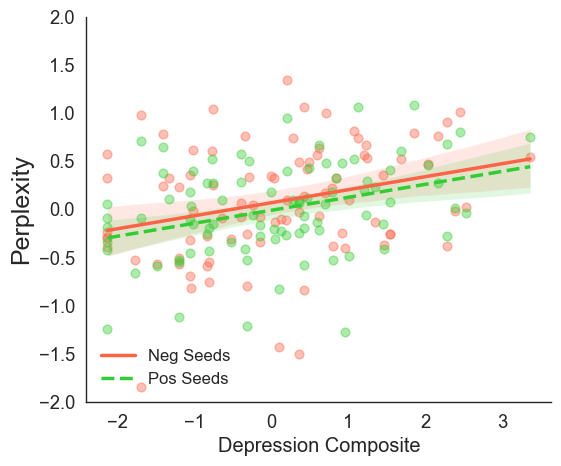

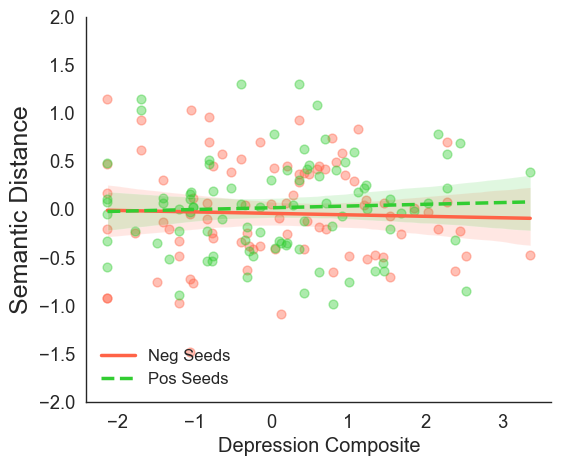

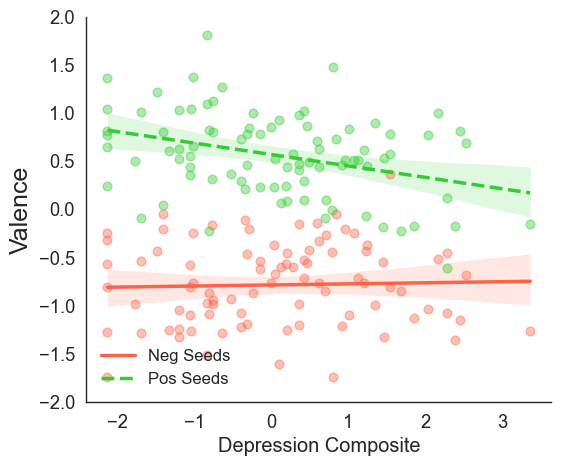

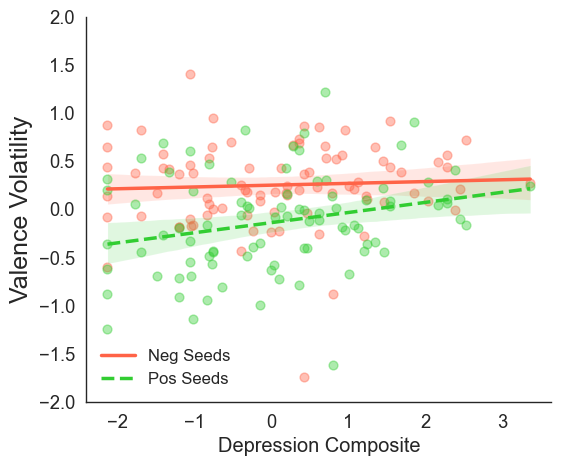

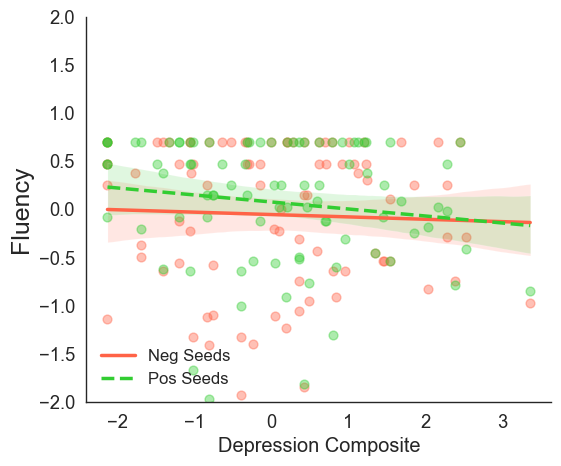

In [67]:
t='pc1'
ylabels={'ppx_m':'Perplexity','semdis':'Semantic Distance','valence_m':'Valence','valence_vol':'Valence Volatility','fluency':'Fluency'}
for f in ['ppx_m','semdis','valence_m','valence_vol','fluency']:
    tmp=cfaResultTrial.loc[cfaResultTrial['cueType'].isin(['pos','neg']),['cueType',f,'subid',t]].dropna()
    tmp=tmp.groupby(['subid','cueType']).mean().reset_index()

    fig,ax=plt.subplots(figsize=(6, 5))
    sns.regplot(y=f, x=t, data=tmp[tmp['cueType']=='neg'], ax=ax, color='tomato',
                scatter_kws={'alpha':0.4, 's':40}, line_kws={'lw':2.5,'label':'Neg Seeds'})
    sns.regplot(y=f, x=t, data=tmp[tmp['cueType']=='pos'], ax=ax, color='limegreen', 
                 scatter_kws={'alpha':0.4, 's':40}, line_kws={'lw':2.5,'linestyle': "--",'label':'Pos Seeds'})
    #ax.set_title('Semantic Entrapment', fontweight='bold', pad=15)
    ax.set_xlabel('Depression Composite')
    ax.set_ylim(-2,2)
    ax.set_ylabel(ylabels[f],fontsize=18)
    ax.legend(frameon=False, loc='lower left', fontsize=12)
    sns.despine()
    plt.show()
    plt.close()

# Study 3

In [70]:
datafolder='Data/To/Study3'
projectfolder='Project/Study3'
cueType={}

cueType['pos']=['future','win','beautiful','kindness','mother','strength','joy']
cueType['neg']=['alone','failure','rejection','worry','guilt','pain','anger']

In [71]:
featurelist=['ppx_m','semdis','valence_m','valence_vol','fluency']
cfaResultTrial=pd.read_csv(projectfolder+'result/Study3.csv',index_col=None).drop(['Unnamed: 0'],axis=1)

cfaResultTrial['cueType']=''
cfaResultTrial.loc[cfaResultTrial['cue'].isin(cueType['neg']),'cueType']='neg'
cfaResultTrial.loc[cfaResultTrial['cue'].isin(cueType['pos']),'cueType']='pos'

In [72]:
questionnaire=pd.read_excel(projectfolder+'WWS/WWS_Questionnaires_DATA_cleaned.xlsx').rename(columns={'SUBJECTID':'subid'})
education=questionnaire.groupby('subid').first()[['education']]
colDict={'PHQ':['phq9m_'+str(x) for x in range(1,10)]}
questionnaire['PHQ']=questionnaire[colDict['PHQ']].sum(axis=1,skipna=False)
questionnaire['session']=questionnaire['redcap_event_name'].str.replace('pre_arm_1','Session1').replace('post_arm_1','Session3')
questionnaire=questionnaire.loc[questionnaire['session']=='Session1',['subid','PHQ','GROUP']].dropna()
questionnaire[['PHQ_raw']]=questionnaire[['PHQ']]
questionnaire[['PHQ']] = pt.fit_transform(questionnaire[['PHQ']])

questionnaire['subid']=questionnaire.apply(lambda r: r['subid'] if type(r['subid'])==int else min([int(x) for x in r['subid'].split("/")]),axis=1)
questionnaire=questionnaire.merge(education,on='subid',how='left')


In [73]:
cfaResultTrial=cfaResultTrial.loc[:,['subid','cue','cueType','group']+featurelist]

In [74]:
cfaResultTrial[featurelist].describe()

,ppx_m,semdis,valence_m,valence_vol,fluency
count,602.000000,602.000000,602.000000,602.000000,602.000000
mean,11.498339,0.438630,0.214369,0.547309,10.229236
std,1.251021,0.044633,0.362548,0.205613,1.112899
min,8.071472,0.291719,-0.938000,0.078234,2.000000
25%,10.622534,0.409207,0.006056,0.393459,10.000000
50%,11.505252,0.437063,0.261156,0.522980,11.000000
75%,12.316421,0.470146,0.486980,0.679649,11.000000
max,15.492699,0.593439,0.924833,1.400664,11.000000


In [75]:
cfaResultTrial[featurelist]=pt.fit_transform(cfaResultTrial[featurelist])
cfaResultTrial=cfaResultTrial.merge(questionnaire,on=('subid'),how='left')
cfaResultTrial.describe()

,ppx_m,semdis,valence_m,valence_vol,fluency,PHQ,PHQ_raw,education
count,6.020000e+02,6.020000e+02,6.020000e+02,6.020000e+02,6.020000e+02,588.000000,588.000000,532.000000
mean,1.203910e-15,-8.734246e-16,-1.106535e-16,-3.658941e-16,-1.357349e-16,0.112200,4.309524,6.368421
std,1.000832e+00,1.000832e+00,1.000832e+00,1.000832e+00,1.000832e+00,1.003628,4.226482,1.614313
min,-2.940800e+00,-3.124285e+00,-2.376128e+00,-2.887445e+00,-2.019536e+00,-1.154269,0.000000,3.000000
25%,-6.873571e-01,-6.708639e-01,-7.006018e-01,-7.214474e-01,-6.304420e-01,-1.154269,0.000000,5.000000
50%,3.146048e-02,-5.303884e-02,1.718610e-03,-2.621845e-02,8.509154e-01,0.364868,3.500000,7.000000
75%,6.691739e-01,6.988244e-01,7.450736e-01,7.087579e-01,8.509154e-01,0.951289,7.000000,8.000000
max,2.990424e+00,3.675087e+00,2.506768e+00,3.135797e+00,8.509154e-01,1.647653,15.000000,8.000000


<Axes: xlabel='PHQ_raw', ylabel='Count'>

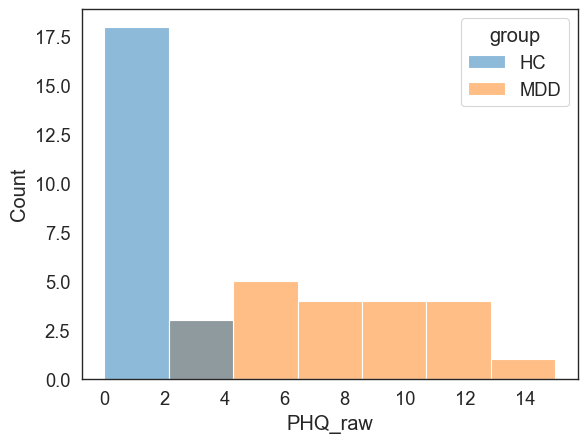

In [76]:
sns.histplot(cfaResultTrial.groupby('subid').first(),x='PHQ_raw',hue='group',alpha=.5)


In [78]:
t='PHQ'
fe_vars=["PHQ","seedType","seedType:PHQ"]
output={}
cfaResultTrial['seedType']=cfaResultTrial['cueType'].map({'neg':-0.5,'pos':0.5})
for f in featurelist:
    print('\n',f)
    tmp=cfaResultTrial[['seedType',f,'subid',t]].dropna()

    model = smf.mixedlm(f"{f} ~ 1", 
                data=tmp, 
                groups=tmp["subid"])
    result1=model.fit(method='powell', maxiter=2000)
    stats1= reportMetrics(result1)
    stats1['model']='Null'
    #print(f'Null Model:  icc={icc:.2f}, aic={aic:.2f}, bic = {bic:.2f}')
    #print(result1.summary())
    model = smf.mixedlm(f"{f} ~  seedType *{t}", 
                data=tmp, 
                groups=tmp["subid"])
    result2=model.fit(method='powell', maxiter=2000)
    print(result2.summary())
    stats2 = reportMetrics(result2,data=tmp,fe_vars=fe_vars)
    stats2['model']='Full'
    
    # Automatically grabs the interaction term (e.g., 'cue_effect:PHQ9')
    interaction_name = f"seedType:{t}"
    
    constraint_neg = result2.model.data.design_info.linear_constraint(f"{t}-0.5*{interaction_name}=0")
    slope_neg = result2.t_test(constraint_neg.coefs)

    print("\n--- Simple Slope: Negative Seeds ---")
    print(slope_neg.summary())
    
    constraint_pos = result2.model.data.design_info.linear_constraint(f"{t}+0.5*{interaction_name}=0")
    slope_pos = result2.t_test(constraint_pos.coefs)
    print("\n--- Simple Slope: Positive Seeds ---")
    print(slope_pos.summary())

    output[f]=(pd.DataFrame([stats1,stats2],columns=['model','Intercept']+fe_vars+['Random_Effect','Subject_Var','Residual_Var','Fit','ICC','AIC/BIC','Marginal_R2']).set_index('model').T.fillna(''))


 ppx_m


         Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: ppx_m    
No. Observations: 588     Method:             REML     
No. Groups:       42      Scale:              0.8509   
Min. group size:  14      Log-Likelihood:     -819.7736
Max. group size:  14      Converged:          Yes      
Mean group size:  14.0                                 
-------------------------------------------------------
             Coef.  Std.Err.   z    P>|z| [0.025 0.975]
-------------------------------------------------------
Intercept     0.001    0.075  0.017 0.987 -0.146  0.148
seedType     -0.010    0.077 -0.133 0.894 -0.160  0.140
PHQ           0.029    0.074  0.390 0.696 -0.117  0.175
seedType:PHQ  0.052    0.076  0.679 0.497 -0.097  0.200
Group Var     0.172    0.059                           


--- Simple Slope: Negative Seeds ---
                             Test for Constraints                             
                 coef    std err          z      P>

         Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: semdis   
No. Observations: 588     Method:             REML     
No. Groups:       42      Scale:              0.8541   
Min. group size:  14      Log-Likelihood:     -817.6434
Max. group size:  14      Converged:          Yes      
Mean group size:  14.0                                 
-------------------------------------------------------
             Coef.  Std.Err.   z    P>|z| [0.025 0.975]
-------------------------------------------------------
Intercept     0.003    0.069  0.048 0.961 -0.132  0.139
seedType      0.214    0.077  2.785 0.005  0.063  0.364
PHQ          -0.124    0.069 -1.802 0.072 -0.258  0.011
seedType:PHQ  0.047    0.076  0.622 0.534 -0.102  0.196
Group Var     0.138    0.050                           


--- Simple Slope: Negative Seeds ---
                             Test for Constraints                             
                 coef    std err          z      P>

         Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: valence_m
No. Observations: 588     Method:             REML     
No. Groups:       42      Scale:              0.6746   
Min. group size:  14      Log-Likelihood:     -740.0856
Max. group size:  14      Converged:          Yes      
Mean group size:  14.0                                 
-------------------------------------------------------
             Coef.  Std.Err.   z    P>|z| [0.025 0.975]
-------------------------------------------------------
Intercept     0.014    0.050  0.275 0.783 -0.084  0.111
seedType      1.032    0.068 15.144 0.000  0.899  1.166
PHQ          -0.098    0.049 -1.991 0.046 -0.194 -0.002
seedType:PHQ  0.149    0.068  2.200 0.028  0.016  0.281
Group Var     0.054    0.029                           


--- Simple Slope: Negative Seeds ---
                             Test for Constraints                             
                 coef    std err          z      P>

          Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: valence_vol
No. Observations: 588     Method:             REML       
No. Groups:       42      Scale:              0.8543     
Min. group size:  14      Log-Likelihood:     -815.4628  
Max. group size:  14      Converged:          Yes        
Mean group size:  14.0                                   
---------------------------------------------------------
               Coef.  Std.Err.   z    P>|z| [0.025 0.975]
---------------------------------------------------------
Intercept      -0.009    0.066 -0.145 0.885 -0.138  0.119
seedType       -0.437    0.077 -5.692 0.000 -0.587 -0.286
PHQ             0.088    0.065  1.348 0.178 -0.040  0.215
seedType:PHQ    0.086    0.076  1.129 0.259 -0.063  0.235
Group Var       0.117    0.045                           


--- Simple Slope: Negative Seeds ---
                             Test for Constraints                             
                 coef 

         Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: fluency  
No. Observations: 588     Method:             REML     
No. Groups:       42      Scale:              0.6388   
Min. group size:  14      Log-Likelihood:     -751.3520
Max. group size:  14      Converged:          Yes      
Mean group size:  14.0                                 
-------------------------------------------------------
             Coef.  Std.Err.   z    P>|z| [0.025 0.975]
-------------------------------------------------------
Intercept     0.005    0.095  0.054 0.957 -0.181  0.192
seedType      0.146    0.066  2.200 0.028  0.016  0.276
PHQ          -0.226    0.094 -2.401 0.016 -0.411 -0.042
seedType:PHQ -0.058    0.066 -0.879 0.379 -0.187  0.071
Group Var     0.330    0.109                           


--- Simple Slope: Negative Seeds ---
                             Test for Constraints                             
                 coef    std err          z      P>

In [79]:
with pd.ExcelWriter(projectfolder+'writeup/study3_PHQ_export.xlsx') as writer:
    for f in featurelist:
        output[f].to_excel(writer,sheet_name=f)

In [80]:
output={}
fe_vars=["group[T.MDD]","seedType","seedType:group[T.MDD]"]

cfaResultTrial['seedType']=cfaResultTrial['cueType'].map({'neg':-0.5,'pos':0.5})
for f in featurelist:
    print('\n',f)
    tmp=cfaResultTrial[['seedType',f,'subid','group']].dropna()
    model = smf.mixedlm(f"{f} ~ 1", 
                data=tmp, 
                groups=tmp["subid"])
    result1=model.fit(method='powell', maxiter=2000)
    stats1= reportMetrics(result1)
    stats1['model']='Null'
    #print(f'Null Model:  icc={icc:.2f}, aic={aic:.2f}, bic = {bic:.2f}')
    #print(result1.summary())
    model = smf.mixedlm(f"{f} ~ seedType*group", 
                data=tmp, 
                groups=tmp["subid"])
    
    result2=model.fit(method='powell', maxiter=2000)
    print(result2.summary())
    stats2 = reportMetrics(result2,data=tmp,fe_vars=fe_vars)
    stats2['model']='Full'
    
    # Automatically grabs the interaction term (e.g., 'cue_effect:PHQ9')
    interaction_name = f"seedType:group[T.MDD]"
    
    constraint_neg = result2.model.data.design_info.linear_constraint(f"group[T.MDD]-0.5*{interaction_name}=0")
    slope_neg = result2.t_test(constraint_neg.coefs)

    print("\n--- Simple Slope: Negative Seeds ---")
    print(slope_neg.summary())
    
    constraint_pos = result2.model.data.design_info.linear_constraint(f"group[T.MDD]+0.5*{interaction_name}=0")
    slope_pos = result2.t_test(constraint_pos.coefs)
    print("\n--- Simple Slope: Positive Seeds ---")
    print(slope_pos.summary())

    output[f]=(pd.DataFrame([stats1,stats2],columns=['model','Intercept']+fe_vars+['Random_Effect','Subject_Var','Residual_Var','Fit','ICC','AIC/BIC','Marginal_R2']).set_index('model').T.fillna(''))



 ppx_m


             Mixed Linear Model Regression Results
Model:               MixedLM    Dependent Variable:    ppx_m    
No. Observations:    602        Method:                REML     
No. Groups:          43         Scale:                 0.8443   
Min. group size:     14         Log-Likelihood:        -835.2296
Max. group size:     14         Converged:             Yes      
Mean group size:     14.0                                       
----------------------------------------------------------------
                      Coef.  Std.Err.   z    P>|z| [0.025 0.975]
----------------------------------------------------------------
Intercept              0.032    0.104  0.302 0.762 -0.173  0.236
group[T.MDD]          -0.062    0.146 -0.423 0.672 -0.347  0.224
seedType               0.008    0.107  0.071 0.943 -0.202  0.218
seedType:group[T.MDD] -0.044    0.150 -0.297 0.767 -0.338  0.249
Group Var              0.168    0.057                           


--- Simple Slope: Negative Seeds ---


             Mixed Linear Model Regression Results
Model:               MixedLM    Dependent Variable:    semdis   
No. Observations:    602        Method:                REML     
No. Groups:          43         Scale:                 0.8445   
Min. group size:     14         Log-Likelihood:        -832.3120
Max. group size:     14         Converged:             Yes      
Mean group size:     14.0                                       
----------------------------------------------------------------
                      Coef.  Std.Err.   z    P>|z| [0.025 0.975]
----------------------------------------------------------------
Intercept              0.133    0.097  1.368 0.171 -0.057  0.323
group[T.MDD]          -0.259    0.136 -1.912 0.056 -0.525  0.007
seedType               0.136    0.107  1.267 0.205 -0.074  0.346
seedType:group[T.MDD]  0.163    0.150  1.089 0.276 -0.130  0.457
Group Var              0.137    0.049                           


--- Simple Slope: Negative Seeds ---


             Mixed Linear Model Regression Results
Model:               MixedLM    Dependent Variable:    valence_m
No. Observations:    602        Method:                REML     
No. Groups:          43         Scale:                 0.6703   
Min. group size:     14         Log-Likelihood:        -752.8306
Max. group size:     14         Converged:             Yes      
Mean group size:     14.0                                       
----------------------------------------------------------------
                      Coef.  Std.Err.   z    P>|z| [0.025 0.975]
----------------------------------------------------------------
Intercept              0.124    0.067  1.854 0.064 -0.007  0.255
group[T.MDD]          -0.243    0.094 -2.591 0.010 -0.426 -0.059
seedType               0.915    0.095  9.576 0.000  0.727  1.102
seedType:group[T.MDD]  0.249    0.134  1.864 0.062 -0.013  0.510
Group Var              0.046    0.026                           


--- Simple Slope: Negative Seeds ---


             Mixed Linear Model Regression Results
Model:               MixedLM   Dependent Variable:   valence_vol
No. Observations:    602       Method:               REML       
No. Groups:          43        Scale:                0.8412     
Min. group size:     14        Log-Likelihood:       -828.6845  
Max. group size:     14        Converged:            Yes        
Mean group size:     14.0                                       
----------------------------------------------------------------
                      Coef.  Std.Err.   z    P>|z| [0.025 0.975]
----------------------------------------------------------------
Intercept             -0.085    0.091 -0.931 0.352 -0.264  0.094
group[T.MDD]           0.166    0.127  1.302 0.193 -0.084  0.416
seedType              -0.560    0.107 -5.235 0.000 -0.770 -0.350
seedType:group[T.MDD]  0.278    0.150  1.856 0.064 -0.016  0.571
Group Var              0.114    0.044                           


--- Simple Slope: Negative Seeds ---


             Mixed Linear Model Regression Results
Model:               MixedLM    Dependent Variable:    fluency  
No. Observations:    602        Method:                REML     
No. Groups:          43         Scale:                 0.6244   
Min. group size:     14         Log-Likelihood:        -761.1305
Max. group size:     14         Converged:             Yes      
Mean group size:     14.0                                       
----------------------------------------------------------------
                      Coef.  Std.Err.   z    P>|z| [0.025 0.975]
----------------------------------------------------------------
Intercept              0.258    0.133  1.944 0.052 -0.002  0.519
group[T.MDD]          -0.505    0.186 -2.717 0.007 -0.869 -0.141
seedType               0.183    0.092  1.989 0.047  0.003  0.364
seedType:group[T.MDD] -0.092    0.129 -0.714 0.475 -0.345  0.161
Group Var              0.326    0.107                           


--- Simple Slope: Negative Seeds ---


In [81]:
with pd.ExcelWriter(projectfolder+'writeup/study3_export.xlsx') as writer:
    for f in featurelist:
        output[f].to_excel(writer,sheet_name=f)

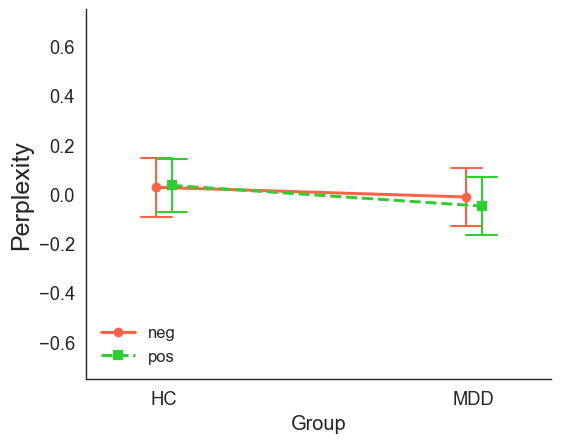

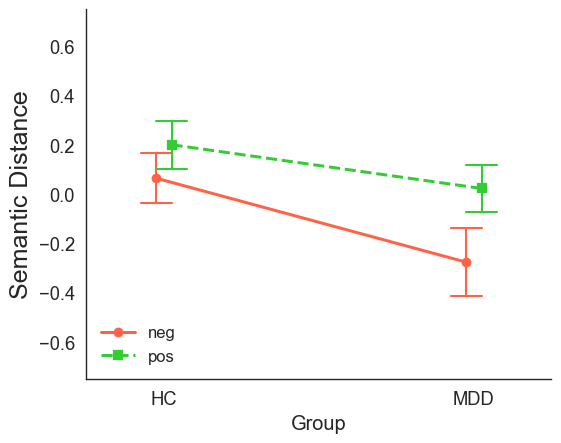

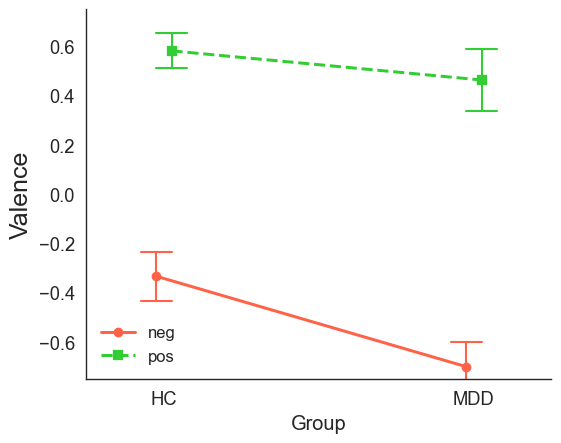

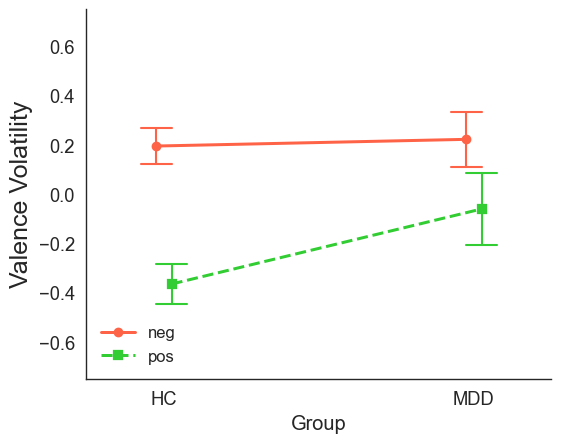

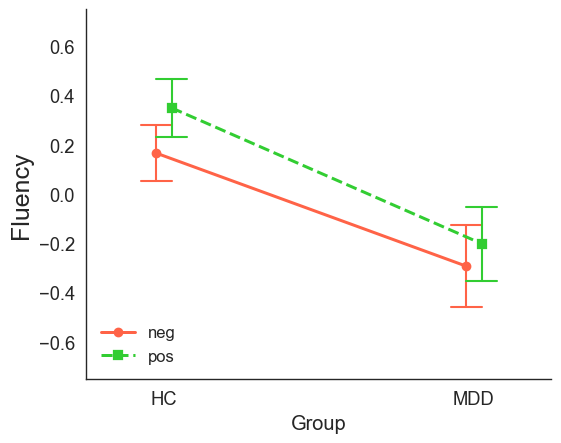

In [82]:
ylabels={'ppx_m':'Perplexity','semdis':'Semantic Distance','valence_m':'Valence','valence_vol':'Valence Volatility','fluency':'Fluency'}
for f in featurelist:
    tmp=cfaResultTrial.loc[:,['cueType',f,'subid','group']].dropna()
    tmp=tmp.groupby(['subid','cueType','group']).mean().reset_index()
    fig,ax=plt.subplots(figsize=(6, 4.8))
    sns.pointplot(data=tmp,
                   x='group', 
                   y=f, 
                   hue="cueType",palette=['tomato','limegreen'],
                   dodge=True, 
                   markers=['o', 's'], 
                   linestyles=['-', '--'],
                   capsize=.1,
                   errorbar="se",
                   err_kws={'linewidth': 1.5},ax=ax)
    #ax.set_title('Semantic Entrapment', fontweight='bold', pad=15)
    ax.set_xlabel('Group')
    ax.set_ylim(-.75,.75)
    ax.set_xlim(-.25,1.25)
    ax.set_ylabel(ylabels[f],fontsize=18)
    ax.legend(frameon=False, loc='lower left', fontsize=12)
    sns.despine()
    plt.show()
    plt.close()